In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(39).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(22).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(62).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(52).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(33).jpg
/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1/Guava Dataset (Original Image)/Guava Dataset (Original Image)/Red rust/Red Rust(68).jpg
/kaggle/input/datasets/abid074/guavadiseasedat

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, ConcatDataset, random_split
import os
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
fruit_classes = ['Phytopthora', 'Scab', 'Styler and Root']

# AlexNet uses 224x224
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_and_relabel(root_path):
    full_ds = datasets.ImageFolder(root_path, transform=transform)
    class_to_idx = {cls_name: i for i, cls_name in enumerate(fruit_classes)}
    filtered_samples = []
    for path, old_label in full_ds.samples:
        cls_name = full_ds.classes[old_label]
        if cls_name in fruit_classes:
            filtered_samples.append((path, class_to_idx[cls_name]))
    full_ds.samples = filtered_samples
    full_ds.imgs = filtered_samples
    full_ds.classes = fruit_classes
    full_ds.class_to_idx = class_to_idx
    return full_ds

base_path = '/kaggle/input/datasets/abid074/guavadiseasedataset-by-rjb/x84p2g3k6z-1'
orig_path = os.path.join(base_path, 'Guava Dataset (Original Image)/Guava Dataset (Original Image)')
aug_path = os.path.join(base_path, 'Guava Disease( Augmented Image)/Guava Disease( Augmented Image)')

full_dataset = ConcatDataset([load_and_relabel(orig_path), load_and_relabel(aug_path)])

train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Total Fruit Images for AlexNet: {len(full_dataset)}")

Total Fruit Images for AlexNet: 3183


In [4]:
# Load AlexNet
model = models.alexnet(weights='DEFAULT')

# AlexNet has a 'classifier' block. We modify the very last layer (index 6).
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, 3)

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("AlexNet model configured for 3 classes.")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 207MB/s] 


AlexNet model configured for 3 classes.


In [5]:
import time

num_epochs = 10

print(f"Starting AlexNet Training on {device}...")

for epoch in range(num_epochs):
    start_time = time.time()
    
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    running_corrects = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Stats
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = running_corrects.double() / len(train_dataset)

    # --- Validation Phase ---
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            _, preds = torch.max(outputs, 1)
            val_running_loss += loss.item() * inputs.size(0)
            val_running_corrects += torch.sum(preds == labels.data)
            
    epoch_val_loss = val_running_loss / len(val_dataset)
    epoch_val_acc = val_running_corrects.double() / len(val_dataset)

    epoch_time = time.time() - start_time

    # --- Display Requirements ---
    print(f'Epoch {epoch+1}/{num_epochs} | Time: {epoch_time:.1f}s')
    print(f'  [Train] Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f}')
    print(f'  [Val]   Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}')
    print("-" * 45)

print("\nAlexNet Training Complete!")

Starting AlexNet Training on cuda...
Epoch 1/10 | Time: 32.5s
  [Train] Loss: 1.2307, Acc: 0.3285
  [Val]   Loss: 1.0980, Acc: 0.3501
---------------------------------------------
Epoch 2/10 | Time: 21.8s
  [Train] Loss: 1.0996, Acc: 0.3411
  [Val]   Loss: 1.1110, Acc: 0.3501
---------------------------------------------
Epoch 3/10 | Time: 21.6s
  [Train] Loss: 1.0987, Acc: 0.3483
  [Val]   Loss: 1.1120, Acc: 0.3501
---------------------------------------------
Epoch 4/10 | Time: 21.9s
  [Train] Loss: 1.1001, Acc: 0.3559
  [Val]   Loss: 1.1005, Acc: 0.3501
---------------------------------------------
Epoch 5/10 | Time: 21.8s
  [Train] Loss: 1.0983, Acc: 0.3546
  [Val]   Loss: 1.1001, Acc: 0.3501
---------------------------------------------
Epoch 6/10 | Time: 21.7s
  [Train] Loss: 1.0967, Acc: 0.3658
  [Val]   Loss: 1.1003, Acc: 0.3187
---------------------------------------------
Epoch 7/10 | Time: 22.0s
  [Train] Loss: 1.0967, Acc: 0.3537
  [Val]   Loss: 1.1000, Acc: 0.3501
--------

In [6]:
model.eval()
test_corrects = 0

print("Final Evaluation on Test Set...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)

test_acc = (test_corrects.double() / len(test_dataset)) * 100
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# Save AlexNet Weights
torch.save(model.state_dict(), '/kaggle/working/alexnet_guava_fruit.pth')
print("Model saved to /kaggle/working/alexnet_guava_fruit.pth")

Final Evaluation on Test Set...

Final Test Accuracy: 36.61%
Model saved to /kaggle/working/alexnet_guava_fruit.pth


Generating predictions for AlexNet Confusion Matrix...


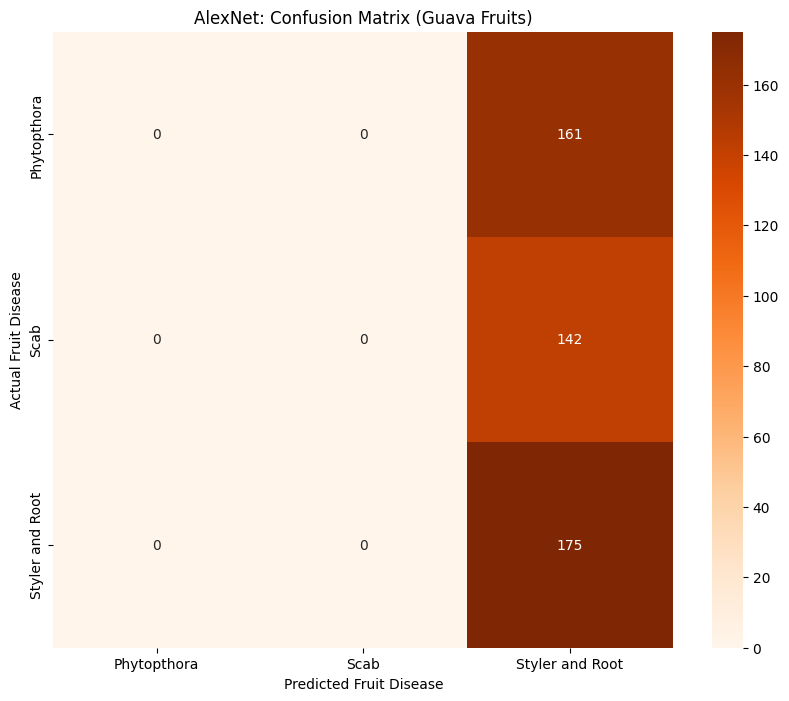


Detailed Classification Report (AlexNet):
                 precision    recall  f1-score   support

    Phytopthora       0.00      0.00      0.00       161
           Scab       0.00      0.00      0.00       142
Styler and Root       0.37      1.00      0.54       175

       accuracy                           0.37       478
      macro avg       0.12      0.33      0.18       478
   weighted avg       0.13      0.37      0.20       478



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Collect all predictions and true labels from the test set
all_preds = []
all_labels = []

model.eval()
print("Generating predictions for AlexNet Confusion Matrix...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Define class names
class_names = ['Phytopthora', 'Scab', 'Styler and Root']

# 3. Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# 4. Plot the heatmap
plt.figure(figsize=(10, 8))
# Using 'Oranges' to distinguish this from your previous model runs
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Fruit Disease')
plt.ylabel('Actual Fruit Disease')
plt.title('AlexNet: Confusion Matrix (Guava Fruits)')
plt.show()

# 5. Print Detailed Metrics
print("\nDetailed Classification Report (AlexNet):")
print(classification_report(all_labels, all_preds, target_names=class_names))

Calculating probabilities for AlexNet ROC Curve...


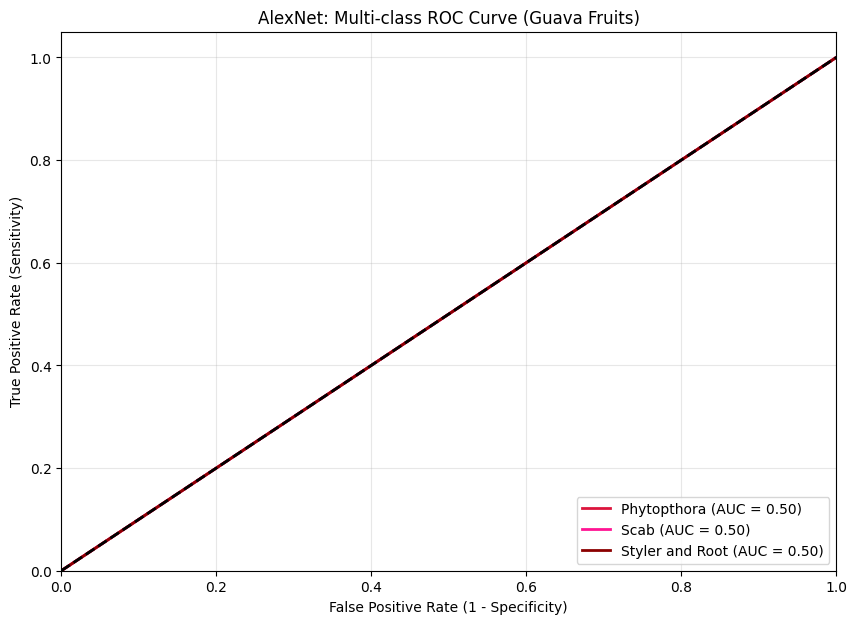

In [8]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Get predicted probabilities
model.eval()
all_probs = []
all_labels = []

print("Calculating probabilities for AlexNet ROC Curve...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        # Softmax converts raw output to probabilities
        probs = torch.nn.functional.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# 2. Prepare labels for 3-class ROC
n_classes = 3
bin_labels = label_binarize(all_labels, classes=[0, 1, 2])
class_names = ['Phytopthora', 'Scab', 'Styler and Root']

# 3. Compute ROC and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(bin_labels[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot the results
plt.figure(figsize=(10, 7))
colors = ['crimson', 'deeppink', 'darkred']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('AlexNet: Multi-class ROC Curve (Guava Fruits)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()